### Workshop 6

### Name: Nayanika Dubey
### Student ID: 2408008


**Sample Code for verifying Directory Structure .**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Unzipped successfully! Path:  {extract_path}")

Unzipped successfully! Path:  /content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon


In [5]:
import os
# Define dataset path
train_dir = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/train"
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


**Sample Code for Checking Corrupted Image**

In [6]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): # Ensure it’s a valid directory
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify() # Verify image integrity
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(img_path)

# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
  for img in corrupted_images:
    print(img)
else:
  print("\nNo corrupted images found.")


No corrupted images found.


**Sample Code for Checking Class Imbalance.**

In [7]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
  class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


**Sample Code for Random Image Selection**

In [8]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
  if images: # Ensure the class folder is not empty
    selected_img = os.path.join(class_path, random.choice(images))
    selected_images.append(selected_img)

**Sample Code for Random Image Plot**

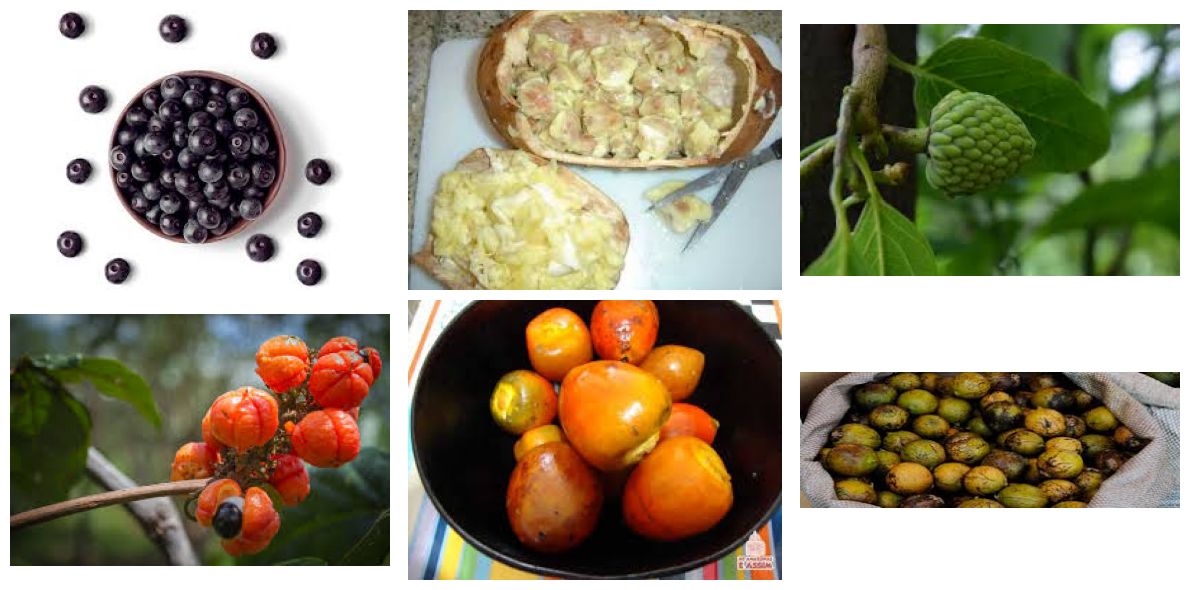

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    # ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

**Generating the Train and Val Dataset.**

**Switching to Devnagari Train Set**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/Copy of devnagari digit.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [12]:
import os
os.listdir("/content/data")

['DevanagariHandwrittenDigitDataset']

In [13]:
import tensorflow as tf
import numpy as np
print(tf.keras.__version__)

3.13.2


In [14]:
train_dir = "/content/data/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/data/DevanagariHandwrittenDigitDataset/Test"

In [15]:
from tensorflow import keras
image_size = (28, 28)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="both",
  seed=1337,
  image_size=image_size,
  batch_size=batch_size,
)

Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Using 3400 files for validation.


In [16]:
for images, labels in train_ds.take(1): # Take one batch
  print("Images shape:", images.shape)
  print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 3)
Labels shape: (32,)


**Visualizing training dataset**

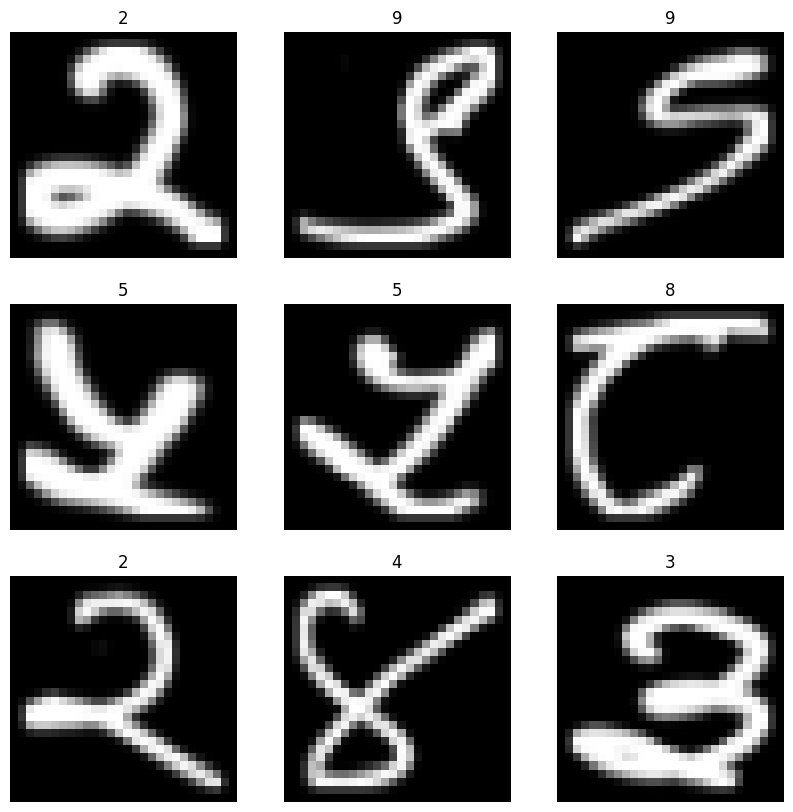

In [17]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Takes one batch of images from the dataset (train_ds).
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(images[i]).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

**ImageDataGenerator**

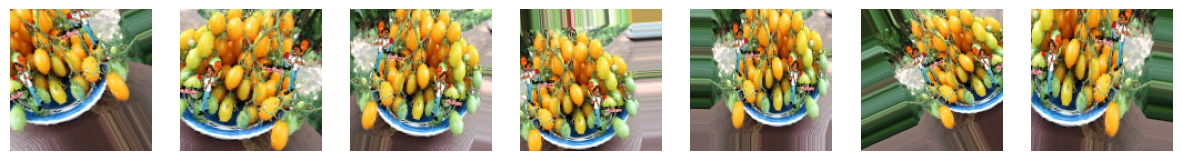

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
  rotation_range=30, # Rotate images by up to 30 degrees
  width_shift_range=0.2, # Shift width by 20%
  height_shift_range=0.2, # Shift height by 20%
  shear_range=0.2, # Shear transformation
  zoom_range=0.2, # Zoom in/out by 20%
  horizontal_flip=True, # Flip images horizontally
  fill_mode='nearest' # Fill in missing pixels
)
# Load an example image
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
img = image.load_img('/content/drive/MyDrive/Colab Notebooks/AI ML/sample.jpg', target_size=(128, 128))
x = image.img_to_array(img) # Convert to NumPy array
x = np.expand_dims(x, axis=0)
# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)
# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
  batch = next(aug_iter)
  ax[i].imshow(batch[0].astype('uint8'))
  ax[i].axis('off')
plt.show()

### Define Augmentation Layers

In [38]:
import tensorflow as tf
from tensorflow.keras import layers

# Define augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),          # Extra augmentation
    layers.RandomContrast(0.1)       # Extra augmentation
]

### Create Augmentation Function

In [39]:
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

### Add Augmentation Inside Model

In [40]:
from tensorflow import keras

model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Apply augmentation here
    *data_augmentation_layers,

    # CNN layers
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

### Visualize Augmented Images

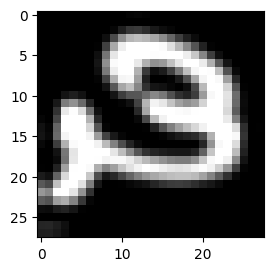

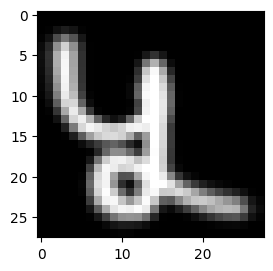

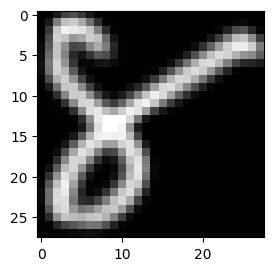

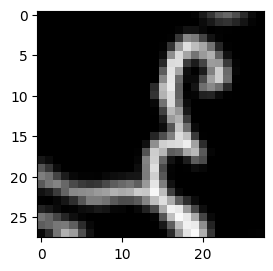

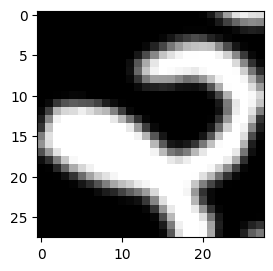

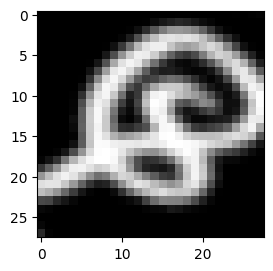

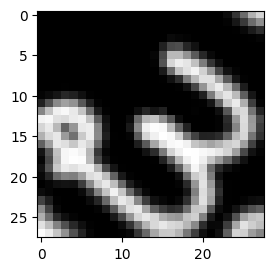

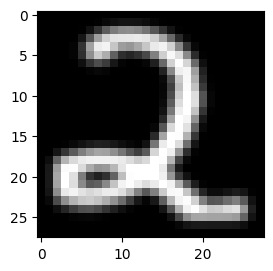

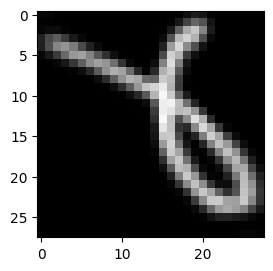

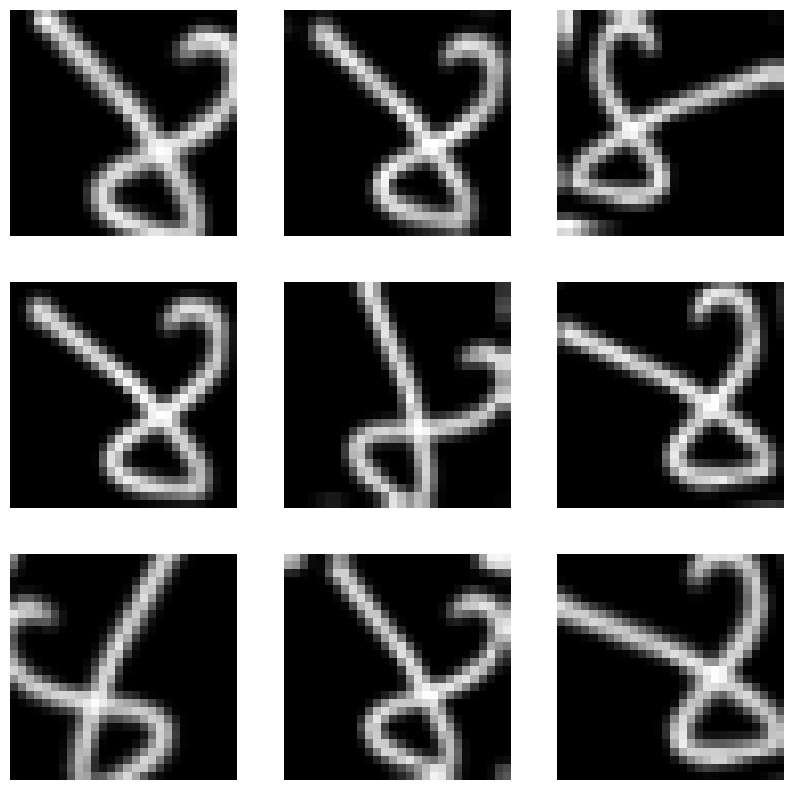

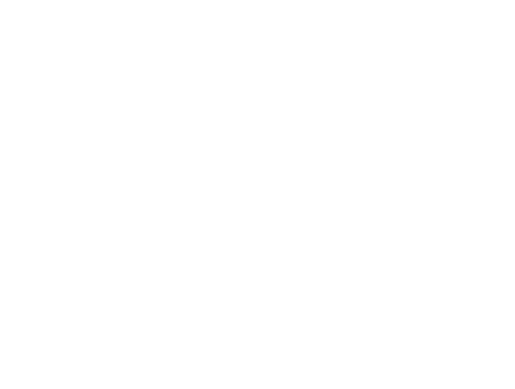

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(images)[0]
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")

plt.show()
plt.axis("off")

plt.show()

### Model Buid

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation

# Data augmentation
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Model
model = Sequential([

    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    # 1st Conv Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 2nd Conv Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 3rd Conv Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 4th Conv Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Dense Layers
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output
    Dense(6, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

### Task 1 – Improved CNN Model (with Augmentation, BN, Dropout)

In [43]:
train_dir = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/train"
test_dir="/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/test"

In [45]:
import os

train_dir = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

print("Classes:", class_names)
print("Total classes:", len(class_names))

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total classes: 6


In [46]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Data Augmentation

In [47]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
]

### Optimize Dataset

In [48]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [49]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

### Improved Deep CNN Model

In [50]:
from tensorflow.keras import models

model = models.Sequential([

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

### Compile Model

In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2778 - loss: 2.3403 - val_accuracy: 0.2778 - val_loss: 1.8396
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.6250 - loss: 1.1028 - val_accuracy: 0.3333 - val_loss: 1.8029
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7083 - loss: 0.8247 - val_accuracy: 0.1111 - val_loss: 1.9857
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.6667 - loss: 0.9200 - val_accuracy: 0.0556 - val_loss: 2.4474
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7222 - loss: 0.7221 - val_accuracy: 0.0556 - val_loss: 3.3314
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.7361 - loss: 0.6252 - val_accuracy: 0.0556 - val_loss: 4.7068
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7778 - loss: 0.6172 - val_accuracy: 0.0556 - val_loss: 6.5143
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 8s/step - accuracy: 0.8333 - loss: 0.4765 - val_accuracy: 0.0556 - val_loss: 8.6131
Epoch 9/15
3/3

### Transfer Learning(VGG16 for fruits)

In [53]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Freeze Layers

In [54]:
for layer in base_model.layers:
    layer.trainable = False

### Add Cusom classifer

In [55]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

### Compile VGG16model

In [56]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train VGG16 model

In [57]:
history_vgg = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 10s/step - accuracy: 0.1389 - loss: 13.6805 - val_accuracy: 0.2222 - val_loss: 7.7811
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.0972 - loss: 11.6891 - val_accuracy: 0.2222 - val_loss: 6.5103
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.2361 - loss: 8.7859 - val_accuracy: 0.2222 - val_loss: 5.5692
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.2500 - loss: 7.9640 - val_accuracy: 0.3889 - val_loss: 4.9673
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.2639 - loss: 7.6143 - val_accuracy: 0.3889 - val_loss: 4.5767
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.3194 - loss: 6.4127 - val_accuracy: 0.4444 - val_loss: 4.3617
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step - accuracy: 0.3333 - loss: 6.3205 - val_accuracy: 0.4444 - val_loss: 4.1955
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 17s/step - accuracy: 0.4444 - loss: 5.4158 - val_accuracy: 0.4444 - val_loss: 4.0306
Epoc

### Model Summary

In [ ]:
model.summary()

### Visualization Graph

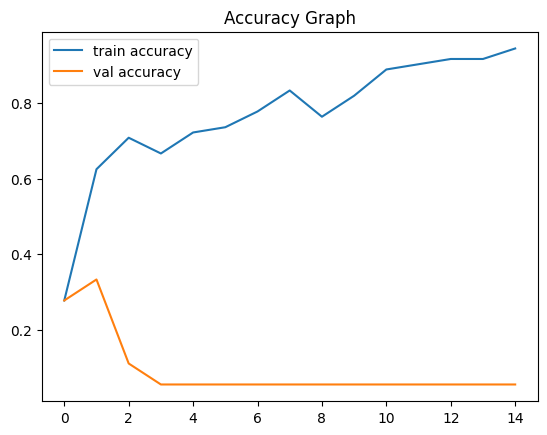

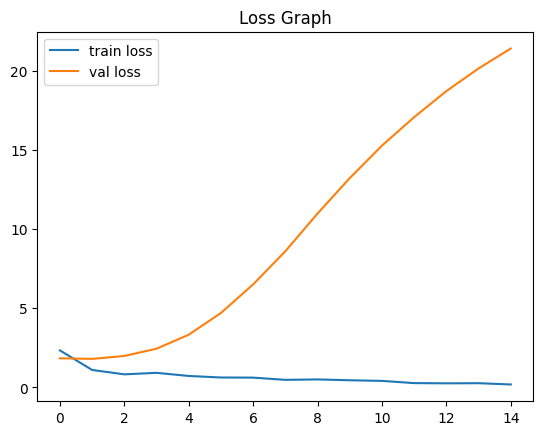

In [58]:

# Accuracy graph
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

### Trained Model VGG16

In [60]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [61]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [62]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

num_classes = 6

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [63]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 26s/step - accuracy: 0.2222 - loss: 6.5458 - val_accuracy: 0.5556 - val_loss: 3.1543
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 26s/step - accuracy: 0.6528 - loss: 1.7435 - val_accuracy: 0.5556 - val_loss: 2.4020
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 28s/step - accuracy: 0.9167 - loss: 0.5041 - val_accuracy: 0.6111 - val_loss: 2.0272
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 24s/step - accuracy: 0.9306 - loss: 0.3065 - val_accuracy: 0.6667 - val_loss: 1.8832
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 24s/step - accuracy: 1.0000 - loss: 0.0223 - val_accuracy: 0.7222 - val_loss: 1.6521


### Evaluate

In [64]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.7222 - loss: 1.6521
Validation Accuracy: 0.7222222089767456


### Inference Output

In [65]:
import numpy as np

predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

y_true = []
for _, y in val_ds:
    y_true.extend(y.numpy())

y_true = np.array(y_true)

print("Predicted:", y_pred[:10])
print("Actual:   ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted: [2 4 2 5 3 5 0 3 4 3]
Actual:    [3 4 4 4 2 4 3 2 5 2]


### Classification Report

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         3
           3       0.20      0.20      0.20         5
           4       0.33      0.25      0.29         4
           5       0.00      0.00      0.00         3

    accuracy                           0.11        18
   macro avg       0.09      0.07      0.08        18
weighted avg       0.13      0.11      0.12        18

